# 04 — Building a pipeline you can defend

**Rahnema College ML Bootcamp 1405** · Week 3 · Peyman Naseri

---

Today is one continuous session with a lunch break in the middle, not two
unrelated ones. The shape of it:

| | | |
|---|---|---|
| **before lunch** | this notebook | build a complete, working pipeline and get a number |
| **after lunch** | notebook 05 | prove that number is too good, and find out by how much |

That is not a teaching device. It is what the job actually feels like: the
first model always looks better than it is, and the work is finding out why
before somebody ships it.

## The problem

Someone hands you a table of past deliveries from four dark stores and asks:

> **When an order comes in, how many minutes until it reaches the customer?**

This is a real product question, not an exercise. The number goes on the
customer's screen as a promise. Promise 15 and take 30 and you lose the
customer; promise 45 to be safe and they never order at all.

## What you should be able to do by the end of the day

1. Take a table you have never seen and get to a defensible number without
   fooling yourself.
2. Name the four ways your validation score can lie to you, and check for each.
3. Say what your model is bad at, in words, before anyone asks.

Week 2's notebook 02 mapped the nine stages of a project. Today we live inside
stages 3, 5 and 6 of that map.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Works whether jupyter was started in the repo root or inside notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid", rc=plt.rcParams)

RANDOM_STATE = 3   # one seed for the whole notebook, so your run matches mine

deliveries = pd.read_csv(DATA / "deliveries.csv", parse_dates=["order_time"])
print(f"{deliveries.shape[0]:,} orders, {deliveries.shape[1]} columns")
print(f"{deliveries['order_time'].min().date()} -> {deliveries['order_time'].max().date()}")
deliveries.head(3)

12,000 orders, 15 columns
2025-09-01 -> 2026-06-27


,order_id,order_time,store,customer_id,courier_id,courier_type,weather,basket_size,basket_value_toman,distance_km,prep_minutes,actual_route_km,rating,tip_toman,delivery_minutes
0,510849,2025-09-01 11:16:00,Vakilabad,U02396,C0061,motorcycle,clear,7,992000,1.50,10.7,2.74,4.0,38000,15.0
1,500138,2025-09-01 11:41:00,Gohardasht,U02062,C0017,motorcycle,clear,5,1236000,1.46,6.4,1.61,4.0,0,19.1
2,501157,2025-09-01 12:33:00,Vakilabad,U02021,C0199,motorcycle,clear,5,474000,3.64,7.7,3.64,4.0,45000,26.3


---

## 1. The question, then the metric — before any modelling

The single most common way to waste a month is to start with `model.fit()` and
decide later what "good" means.

**What are we predicting?** `delivery_minutes`, a positive number. Regression.

**Which metric?** Three candidates, and the choice is a business decision, not
a statistical one:

| Metric | What it optimises | When you want it |
|---|---|---|
| **MAE** | the typical error | you care about the median customer |
| **RMSE** | squared error, so big misses dominate | one 40-minute delivery hurts more than eight 5-minute ones |
| **Pinball loss** | a chosen quantile | you want a promise you keep 90% of the time |

We use **MAE, in minutes**, for two reasons. It is in the unit the business
already thinks in — "we are off by five minutes" needs no translation — and
the target has a long right tail, which would let RMSE be dominated by a
handful of incidents.

Worth saying out loud: the *right* answer for an ETA promise is arguably the
pinball loss at the 80th or 90th percentile, because a promise you keep half
the time is not a promise. We use MAE today because it is the clearest thing
to teach on; on a real project I would push for the quantile.

count    12000.0
mean        21.2
std          8.7
min          3.0
10%         10.8
50%         20.4
90%         32.4
99%         45.8
max         81.5


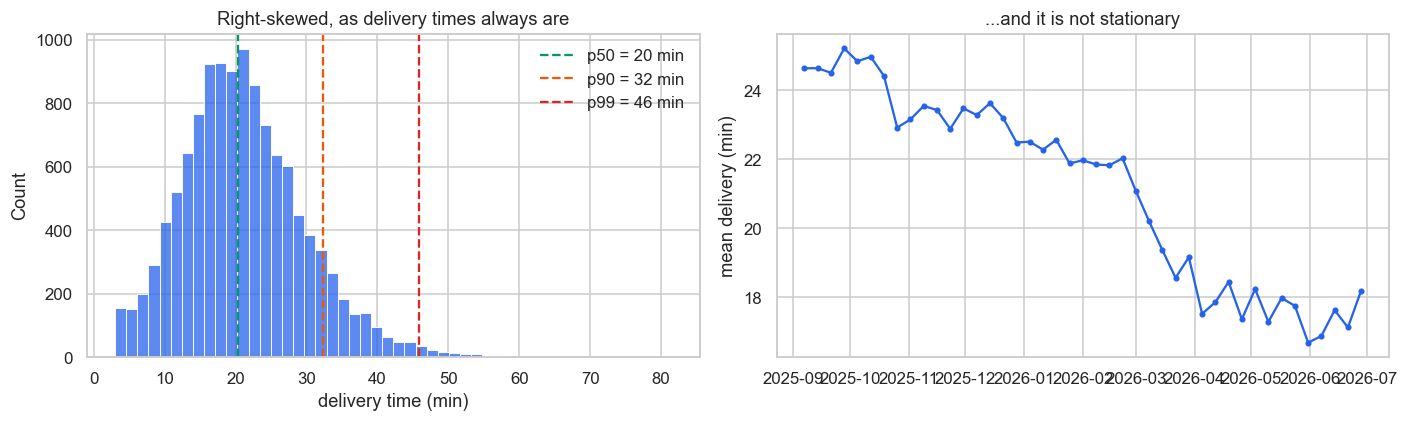

In [2]:
target = deliveries["delivery_minutes"]

# Percentiles, not just the mean -- the tail is the part that hurts customers.
print(target.describe(percentiles=[0.1, 0.5, 0.9, 0.99]).round(1).to_string())

fig, (ax_hist, ax_time) = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(target, bins=50, ax=ax_hist, color="#2563eb")
for q, c in [(0.5, "#059669"), (0.9, "#ea580c"), (0.99, "#dc2626")]:
    ax_hist.axvline(target.quantile(q), ls="--", lw=1.5, color=c,
                    label=f"p{int(q*100)} = {target.quantile(q):.0f} min")
ax_hist.set(xlabel="delivery time (min)", title="Right-skewed, as delivery times always are")
ax_hist.legend(frameon=False)

# The other thing to check before modelling: does the target drift over time?
daily = deliveries.set_index("order_time")["delivery_minutes"].resample("W").mean()
ax_time.plot(daily.index, daily.values, marker="o", ms=3, color="#2563eb")
ax_time.set(ylabel="mean delivery (min)", title="...and it is not stationary")
fig.tight_layout()

Hold on to that right-hand plot. Deliveries are getting **faster** over the
period — the fleet grew and the dispatch logic was replaced partway through.

A target that drifts is a warning about how we validate, and we will collect
on that warning after lunch. For now, note it and keep going.

---

## 2. Split first. Everything else second.

This is the rule I promised you last week, and it is first for a reason: the
moment you compute anything from the full dataset — a median for imputation, a
scaler's mean, a category list — the test set has touched your model, and your
estimate of how well it works is no longer honest.

So: split now, before we even look at the columns properly.

We use a plain random split today because it is the default that everyone
reaches for. **Whether it is the right split for this data is a question we
come back to after lunch.**

In [3]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(deliveries, test_size=0.2, random_state=RANDOM_STATE)

print(f"train: {len(train):,} rows")
print(f"test : {len(test):,} rows")

# From here on, `test` is untouchable. We look at it once, at the very end of
# the day. Everything we decide is decided using `train` alone.

train: 9,600 rows
test : 2,400 rows


---

## 3. A stupid baseline, before a clever model

Until you have a number to beat, you cannot tell whether your model is good —
only whether it runs.

The baseline should be something the business could do without you. Here:
*"predict the median delivery time, always."* If a gradient boosting model
cannot beat that by a wide margin, the honest answer is that this problem does
not need a model.

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

# DummyRegressor still needs an X of the right length to know how many
# predictions to make, so we hand it one column and it ignores the contents.
FEATURES_PLACEHOLDER = ["distance_km"]   # DummyRegressor ignores X entirely

baseline = DummyRegressor(strategy="median")
baseline.fit(train[FEATURES_PLACEHOLDER], train["delivery_minutes"])

baseline_mae = mean_absolute_error(
    test["delivery_minutes"], baseline.predict(test[FEATURES_PLACEHOLDER]))

print(f"always predict {baseline.constant_[0][0]:.1f} minutes")
print(f"baseline MAE on the test set: {baseline_mae:.2f} minutes")

always predict 20.3 minutes
baseline MAE on the test set: 6.72 minutes


---

## 4. Sort the columns before you use them

Now we look at what we have. Not "which columns are numeric" — that is the easy
part — but the question that actually matters:

> **Was this value known at the moment the order was placed?**

Anything recorded *during or after* the delivery cannot be a feature, no matter
how predictive it is, because at prediction time it does not exist yet.

In [5]:
# dtypes first, then what is missing. Only two columns have gaps, and both
# are ones we can impute -- but we want to know that before we design the
# preprocessing, not after it silently drops rows.
print(deliveries.dtypes.to_string())
print("\nmissing values:")
print(deliveries.isna().sum()[lambda s: s > 0].to_string())

order_id                       int64
order_time            datetime64[ns]
store                         object
customer_id                   object
courier_id                    object
courier_type                  object
weather                       object
basket_size                    int64
basket_value_toman             int64
distance_km                  float64
prep_minutes                 float64
actual_route_km              float64
rating                       float64
tip_toman                      int64
delivery_minutes             float64

missing values:
weather         900
prep_minutes    240


Going column by column and asking that one question:

| Column | Known when the order is placed? | Verdict |
|---|---|---|
| `store`, `courier_type`, `weather` | yes | **feature** |
| `basket_size`, `basket_value_toman` | yes | **feature** |
| `distance_km` | yes — the straight-line estimate | **feature** |
| `prep_minutes` | yes — the store's own estimate | **feature** |
| `order_time` | yes | **feature**, once we turn it into hour / weekday |
| `courier_id`, `customer_id` | yes | *hold* — see after lunch, these are traps |
| `actual_route_km` | **no** — measured after the trip | ❌ leak |
| `rating` | **no** — the customer rates afterwards | ❌ leak |
| `tip_toman` | **no** — paid on delivery | ❌ leak |
| `delivery_minutes` | it *is* the answer | target |

Three columns are set aside. After lunch we measure exactly what each one
would have bought us, and why taking it would have been a disaster.

`courier_id` and `customer_id` are the interesting case: they *are* known at
order time, so they pass the availability test. They still cause two different
disasters, for reasons that have nothing to do with availability. That is the
second half of the day.

In [6]:
# Known at the moment the order is placed.
NUMERIC = ["distance_km", "prep_minutes", "basket_size", "basket_value_toman"]
CATEGORICAL = ["store", "courier_type", "weather"]

# Recorded during or after the delivery. Never features.
LEAKY = ["actual_route_km", "rating", "tip_toman"]

TARGET = "delivery_minutes"


def add_time_features(df):
    """Turn the timestamp into things a model can use.

    A raw datetime is useless to a tree: it will happily split on "before
    14 March" and learn the calendar instead of the behaviour. Hour and
    weekday are what actually drive delivery time.
    """
    return df.assign(
        hour=df["order_time"].dt.hour,
        weekday=df["order_time"].dt.dayofweek,
        is_evening=(df["order_time"].dt.hour >= 19).astype(int),
    )


TIME_FEATURES = ["hour", "weekday", "is_evening"]
FEATURES = NUMERIC + TIME_FEATURES + CATEGORICAL

train = add_time_features(train)
test = add_time_features(test)

print(f"{len(FEATURES)} features:", ", ".join(FEATURES))
print(f"{len(LEAKY)} columns set aside:", ", ".join(LEAKY))

10 features: distance_km, prep_minutes, basket_size, basket_value_toman, hour, weekday, is_evening, store, courier_type, weather
3 columns set aside: actual_route_km, rating, tip_toman


---

## 5. ColumnTransformer and Pipeline

Numeric columns and categorical columns need different treatment, and every
treatment has to be *learned from the training fold only*. Doing that by hand,
in the right order, every time, is how people make mistakes.

`ColumnTransformer` routes each group of columns down its own branch;
`Pipeline` glues the whole thing — preprocessing and model — into a single
object with one `fit` and one `predict`.

This is the figure to keep in your head:

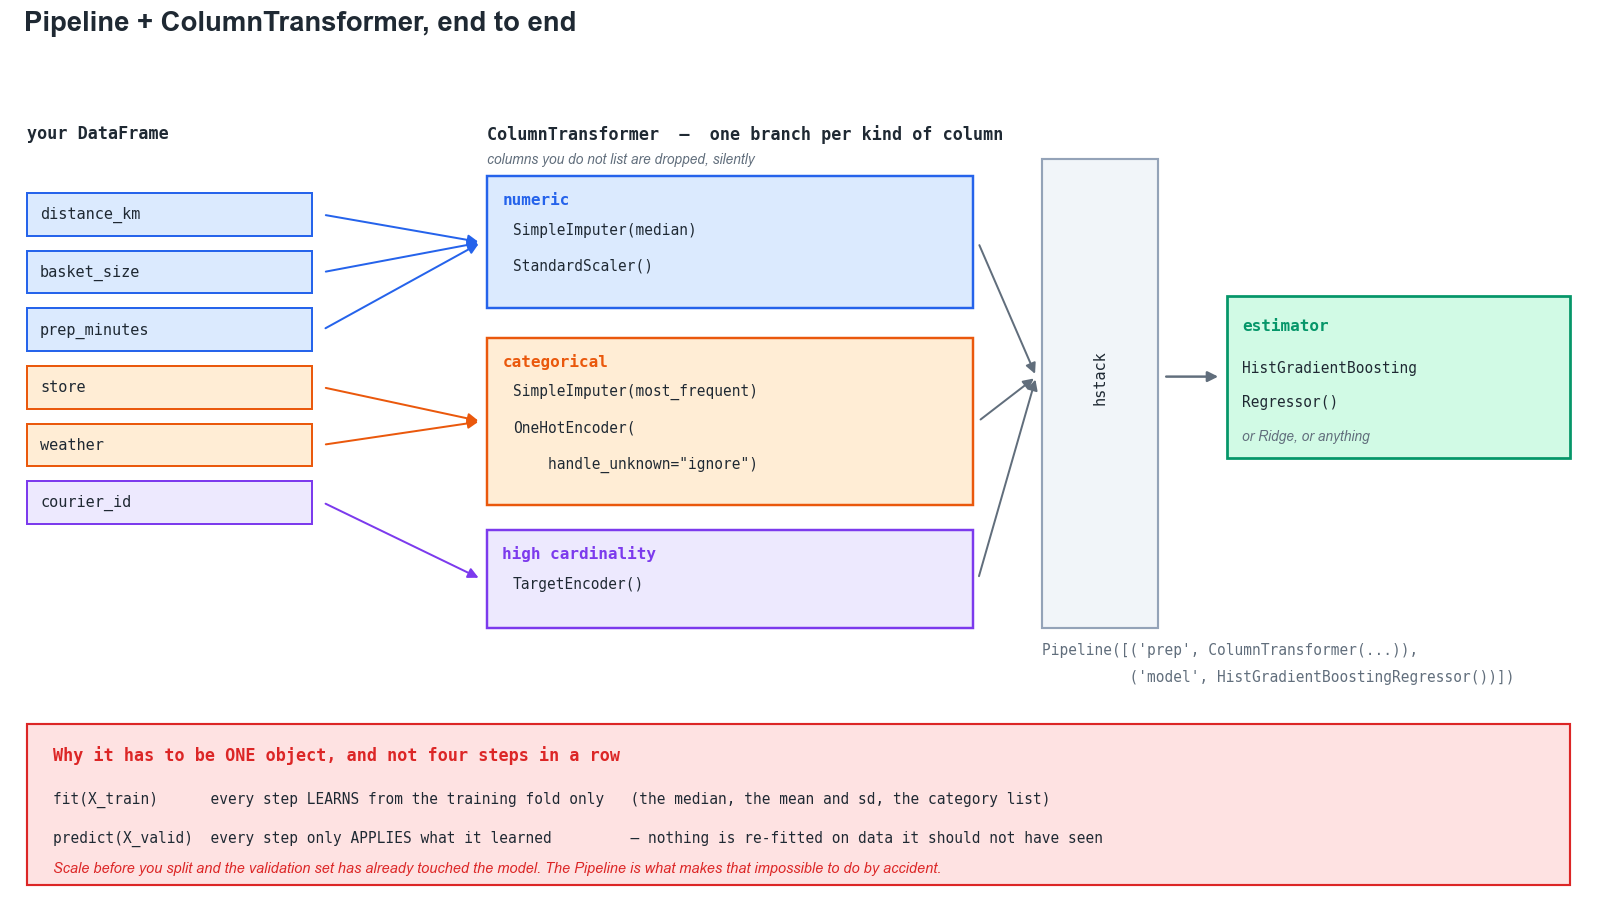

In [7]:
import sys
sys.path.insert(0, str(ROOT))
from bootcamp import pipeline_anatomy, cv_schemes

pipeline_anatomy();   # also assets/pipeline_anatomy.png

The red band at the bottom is the whole reason this exists. When you call
`fit`, every step learns from the training data. When you call `predict`,
every step only *applies* what it learned. Written as four separate steps in a
notebook, that discipline is on you and you will eventually get it wrong.
Written as a `Pipeline`, it is impossible to get wrong.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_branch = Pipeline([
    # `prep_minutes` has a few hundred missing values. The median is learned
    # from the training fold, which is exactly what we want.
    ("impute", SimpleImputer(strategy="median")),
    # Trees do not need scaling, but linear models do, and keeping it here
    # means we can swap the model without rewriting the preprocessing.
    ("scale", StandardScaler()),
])

categorical_branch = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # handle_unknown="ignore" is not optional: a category that appears only in
    # the test set would otherwise raise at predict time, in production, at
    # 2am. sparse_output=False because HistGradientBoosting wants dense input.
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_branch, NUMERIC + TIME_FEATURES),
    ("cat", categorical_branch, CATEGORICAL),
])
# Anything not listed above is dropped. That is the default, and it is the
# safe default: a column has to be named to get anywhere near the model.

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['distance_km', 'prep_minutes', 'basket_size',
                                  'basket_value_toman', 'hour', 'weekday',
                                  'is_evening']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['store', 'courier_type', 'weather'])])

Notice what that display shows you: sklearn renders the whole structure as an
interactive diagram. Click through it in your own notebook — it is the fastest
way to check you built what you meant to build.

Now the model. `HistGradientBoostingRegressor` is the sensible default for
tabular data in 2026: fast, handles non-linearity and interactions on its own,
and needs almost no tuning to be respectable. Start here, and only reach for
anything fancier once you have a reason.

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

# The Pipeline is a single estimator: this one .fit call runs the imputers,
# the scaler, the encoder and the model, in that order, all learning from
# `train` only.
model = Pipeline([
    ("prep", preprocess),
    ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
])

model.fit(train[FEATURES], train[TARGET])

holdout_mae = mean_absolute_error(test[TARGET], model.predict(test[FEATURES]))
print(f"baseline MAE : {baseline_mae:.2f} min")
print(f"model MAE    : {holdout_mae:.2f} min")
print(f"improvement  : {(1 - holdout_mae / baseline_mae) * 100:.0f}%")

baseline MAE : 6.72 min
model MAE    : 4.74 min
improvement  : 29%


---

## 6. One number is not a result

That test score came from one split. Change `random_state` and it moves. How
much it moves is information you need, and a single number hides it.

`cross_validate` refits the entire pipeline on each fold — preprocessing
included — which is the only reason the score means anything.

In [10]:
from sklearn.model_selection import cross_validate, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cross_validate clones the pipeline and refits it from scratch on each fold,
# preprocessing included. That is the whole reason the score is trustworthy:
# fold 3's imputer never saw fold 3's rows.
scores = cross_validate(
    model, train[FEATURES], train[TARGET], cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,   # the gap to train score tells you about overfitting
)

fold_mae = -scores["test_score"]
print("fold MAEs:", np.round(fold_mae, 2))
print(f"\ncross-validated MAE: {fold_mae.mean():.2f}  +/- {fold_mae.std():.2f}")
print(f"train-fold MAE     : {-scores['train_score'].mean():.2f}"
      "   (much lower would mean overfitting)")

fold MAEs: [5.02 4.92 4.99 4.79 4.96]

cross-validated MAE: 4.94  +/- 0.08
train-fold MAE     : 4.18   (much lower would mean overfitting)


The fold-to-fold spread is the number to quote alongside the mean. A model at
"4.9 ± 0.1" and a model at "4.9 ± 0.8" are not the same model, and a
0.05-minute improvement over a competitor means nothing if your folds disagree
by 0.8.

---

## 7. Where we are

In [11]:
# All three numbers together, because each one answers a different question:
# is the model worth anything, what does one split say, and how much does the
# answer move when the split changes.
scoreboard = pd.DataFrame([
    {"step": "always predict the median", "MAE (min)": baseline_mae},
    {"step": "pipeline, single holdout", "MAE (min)": holdout_mae},
    {"step": "pipeline, 5-fold CV", "MAE (min)": fold_mae.mean()},
]).round(2)

print(scoreboard.to_string(index=False))
print(f"\nwe are typically {fold_mae.mean():.1f} minutes off, "
      f"against a {deliveries[TARGET].median():.0f}-minute median delivery")

                     step  MAE (min)
always predict the median       6.72
 pipeline, single holdout       4.74
      pipeline, 5-fold CV       4.94

we are typically 4.9 minutes off, against a 20-minute median delivery


So: a complete, honest-looking pipeline that beats a sensible baseline by a
comfortable margin, cross-validated, with no obvious mistakes. On a lot of
teams this is where the work stops and the slide gets made.

**It is also wrong, and after lunch we find out by how much.**

Three things we have quietly left on the table, in the order we will pick them
up:

1. Three columns we set aside — we never measured what taking them would have
   done. It is worth seeing the size of the mistake we did not make.
2. `courier_id` and `customer_id` are legitimate features by the availability
   test, and both of them will destroy this model in two different ways.
3. That random split. The target drifts over time and we shuffled the rows
   anyway.

☕ **See you at 14:00.** Notebook 05.